C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Silhouette Score Blobs (Выпуклые): 0.9084
Silhouette Score Moons (Полумесяцы): 0.4297


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Silhouette Score Circles (Окружности): 0.3805


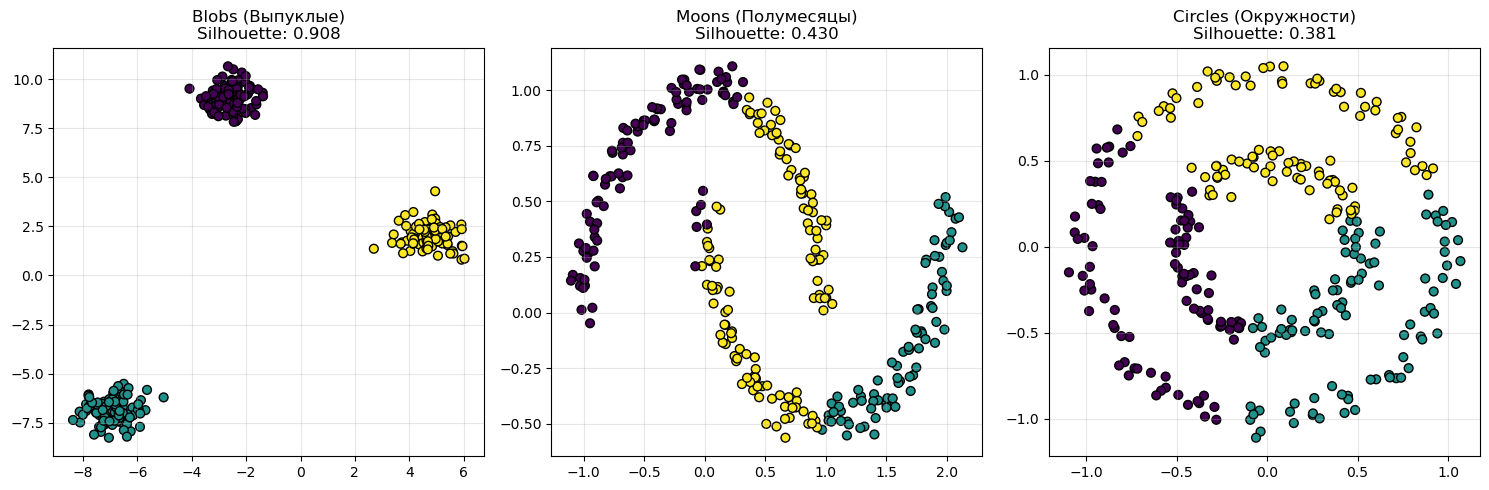

In [13]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_moons, make_circles, make_blobs 
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors



X1, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42)
X2, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
X3, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

datasets = [X1, X2, X3]
titles = ['Blobs (Выпуклые)', 'Moons (Полумесяцы)', 'Circles (Окружности)']

plt.figure(figsize=(15, 5))

for i, X in enumerate(datasets):
    
    kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)
    print(f'Silhouette Score {titles[i]}: {score:.4f}')

    plt.subplot(1, 3, i + 1)
    
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolor='k', s=40)
    plt.title(f'{titles[i]}\nSilhouette: {score:.3f}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

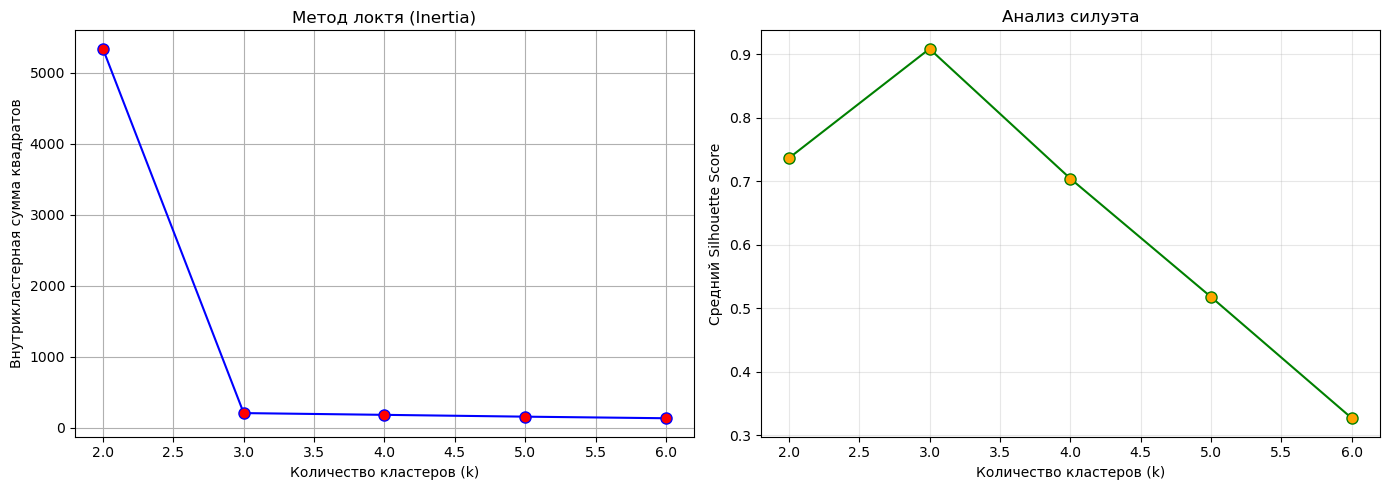

In [11]:
clusters_range = [2, 3, 4, 5, 6]
inertias = []
silhouettes = []

for k in clusters_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X1)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X1, labels))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(clusters_range, inertias, 'bo-', markerfacecolor='red', markersize=8)
ax1.set_title('Метод локтя (Inertia)')
ax1.set_xlabel('Количество кластеров (k)')
ax1.set_ylabel('Внутрикластерная сумма квадратов')
ax1.grid(True)


ax2.plot(clusters_range, silhouettes, 'go-', markerfacecolor='orange', markersize=8)
ax2.set_title('Анализ силуэта')
ax2.set_xlabel('Количество кластеров (k)')
ax2.set_ylabel('Средний Silhouette Score')
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

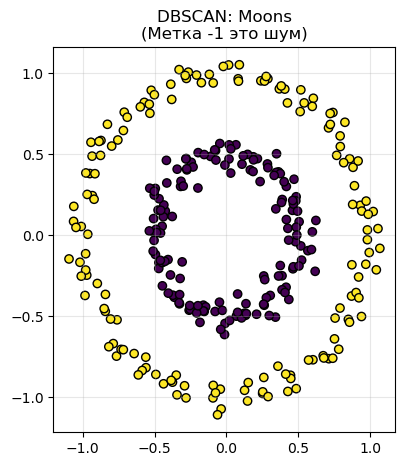

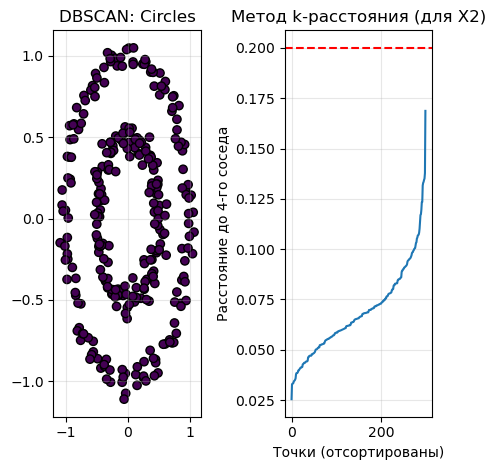

In [21]:
dbscan_x2= DBSCAN(eps = 0.3 , min_samples =5).fit(X2)
dbscan_x3 = DBSCAN(eps = 0.3 , min_samples = 5).fit(X3)

plt.figure(figsize = (15,5))

plt.subplot(1,3,1)
plt.scatter(X[:, 0] , X[:,1], c = dbscan_x2.labels_, cmap= 'viridis', edgecolor = 'k')
plt.title("DBSCAN: Moons\n(Метка -1 это шум)")
plt.grid(True, alpha = 0.3)
plt.show() 


plt.subplot(1, 3, 2)
plt.scatter(X3[:, 0], X3[:, 1], c=dbscan_x3.labels_, cmap='viridis', edgecolor='k')
plt.title("DBSCAN: Circles")
plt.grid(True, alpha=0.3)

neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X2)
distances, indices = neighbors_fit.kneighbors(X2)
distances = np.sort(distances[:, 3] , axis = 0)

plt.subplot(1, 3, 3)
plt.plot(distances)
plt.title("Метод k-расстояния (для X2)")
plt.xlabel("Точки (отсортированы)")
plt.ylabel("Расстояние до 4-го соседа")
plt.axhline(y=0.2, color='r', linestyle='--') 
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


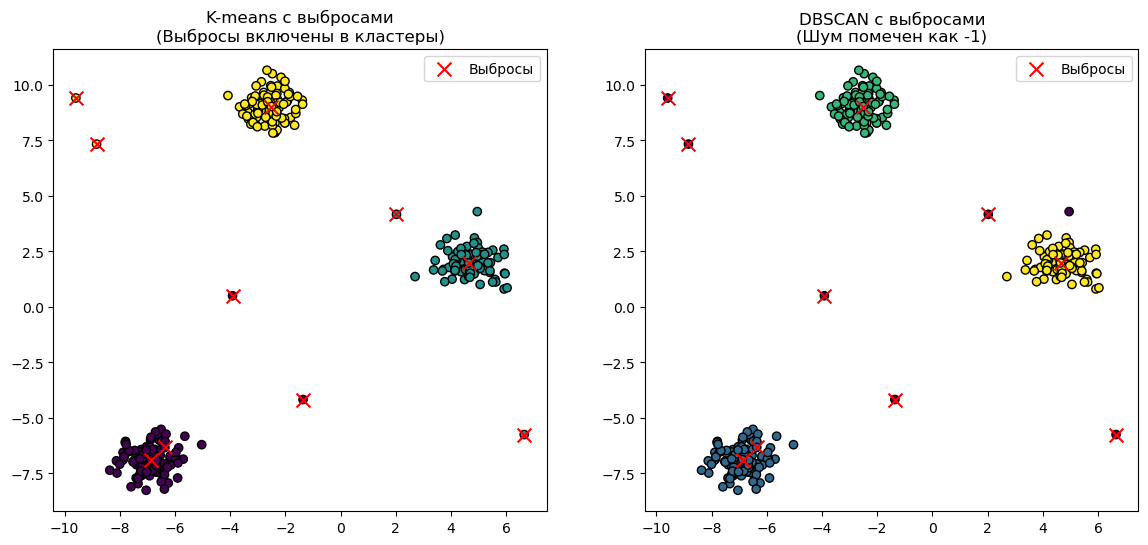

Выбросов включено в кластеры (K-means): 10
Выбросов выделено как шум (DBSCAN): 7


In [23]:

np.random.seed(42)

outliers = np.random.uniform(low=-10, high=10, size=(10, 2))
X1_with_outliers = np.vstack([X1, outliers])


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X1_with_outliers)

dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X1_with_outliers)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X1_with_outliers[:, 0], X1_with_outliers[:, 1], c=km_labels, cmap='viridis', edgecolor='k')
plt.scatter(outliers[:, 0], outliers[:, 1], c='red', marker='x', s=100, label='Выбросы')
plt.title("K-means с выбросами\n(Выбросы включены в кластеры)")
plt.legend()


plt.subplot(1, 2, 2)
plt.scatter(X1_with_outliers[:, 0], X1_with_outliers[:, 1], c=db_labels, cmap='viridis', edgecolor='k')
plt.scatter(outliers[:, 0], outliers[:, 1], c='red', marker='x', s=100, label='Выбросы')
plt.title("DBSCAN с выбросами\n(Шум помечен как -1)")
plt.legend()

plt.show()


n_noise_dbscan = list(db_labels).count(-1)
print(f"Выбросов включено в кластеры (K-means): {len(outliers)}")
print(f"Выбросов выделено как шум (DBSCAN): {n_noise_dbscan}")